# Source Injector

The source injector can produce mock simulated data independent of the MEGAlib software.

Standard data simulation requires the users to install and use MEGAlib to convolve the source model with the detector effects to generate data. The source injector utilizes the response generated by intensive simulation, which contains the statistical detector effects. With the source injector, you can convolve response, source model, and orientation to gain the mock data quickly. 

The advantages of using the source injector include:

- No need to install and use MEGAlib
- Get the data much faster than the standard simulation pipeline
- The generated data are in the format that can be used for spectral fitting, localization, imaging, etc.

The disadvantages are:

- The data are binned based on the binning of the response, which means that you lost the unbinned event distribution as you will get from the MEGAlib pipeline.
- If the response is coarse, the data you generated might not be precise.

In [1]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
from pathlib import Path
from astropy.coordinates import SkyCoord
from astromodels.functions.function import Function1D, FunctionMeta
from cosipy import SpacecraftFile, SourceInjector
from histpy import Histogram
from threeML import Powerlaw, Band, Model, PointSource, Cutoff_powerlaw
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file
import shutil
import os
import h5py as h5

%matplotlib inline

In [2]:
data_dir = Path("/Users/parshadkp/Software/COSI_Data/")

## Get the data
The data can be downloaded by running the cells below. Each respective cell also gives the wasabi file path and file size. 

In [3]:
response_path = data_dir/"DC3_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5"

In [4]:
%%capture
orientation_path = data_dir/"DC3_Files/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori" # DC3

# Power law tail

## Cutoff-Powerlaw for normalization value

### 200 keV Cutoff

In [5]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

In [6]:
K_inj = 0.15*spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

# print(spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))

In [46]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=155.0770628414967, b=75.0630654405054, frame = "galactic", unit = "deg")

# define the Crab point source
# point_source = PointSource('NGC4151_ec200_PL', l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape = (spectrum_inj_ec200 + spectrum_inj_ec200_PL))
point_source = PointSource('NGC4151_ec200', l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape = spectrum_inj_ec200)

# define the model. One model can contain multiple point sources.
model = Model(point_source)

### 1000 keV Cutoff

In [38]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

In [39]:
K_inj = (spectrum_inj_ec200_PL.evaluate_at(200)) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

In [40]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=155.0770628414967, b=75.0630654405054, frame = "galactic", unit = "deg")

# define the Crab point source
# point_source = PointSource('NGC4151_ec1000_PL', l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape = (spectrum_inj_ec1000 + spectrum_inj_ec1000_PL))
point_source = PointSource('NGC4151_ec1000', l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape = spectrum_inj_ec1000)

# define the model. One model can contain multiple point sources.
model = Model(point_source)

### NGC 4151 Faint

In [19]:
K_inj = 0.035 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.81

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

In [20]:
K_inj = (spectrum_inj_ec200_PL.evaluate_at(200)) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

In [21]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=155.0770628414967, b=75.0630654405054, frame = "galactic", unit = "deg")

# define the Crab point source
point_source = PointSource('NGC4151_ec1000_PL', l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape = (spectrum_inj_ec1000 + spectrum_inj_ec1000_PL))

# define the model. One model can contain multiple point sources.
model = Model(point_source)

### NGC 4151 Bright

In [31]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 264. * u.keV
index_inj = -1.71

spectrum_inj_ec264 = Cutoff_powerlaw()

spectrum_inj_ec264.K.value = K_inj.value
spectrum_inj_ec264.piv.value = piv_inj.value
spectrum_inj_ec264.xc.value = xc_inj.value
spectrum_inj_ec264.index.value = index_inj

spectrum_inj_ec264.K.unit = K_inj.unit
spectrum_inj_ec264.piv.unit = piv_inj.unit
spectrum_inj_ec264.xc.unit = xc_inj.unit

In [32]:
K_inj = (spectrum_inj_ec200_PL.evaluate_at(200)) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec264_PL = Powerlaw()

spectrum_inj_ec264_PL.K.value = K_inj.value
spectrum_inj_ec264_PL.piv.value = piv_inj.value
spectrum_inj_ec264_PL.index.value = index_inj

spectrum_inj_ec264_PL.K.unit = K_inj.unit
spectrum_inj_ec264_PL.piv.unit = piv_inj.unit

In [33]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=155.0770628414967, b=75.0630654405054, frame = "galactic", unit = "deg")

# define the Crab point source
point_source = PointSource('NGC4151_ec264_PL', l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape = (spectrum_inj_ec264 + spectrum_inj_ec264_PL))

# define the model. One model can contain multiple point sources.
model = Model(point_source)

## Point Source Creator

In [34]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.parse_from_file(orientation_path)

In [35]:
# Define an injector by the response
injector = SourceInjector(response_path = response_path)
# injector = SourceInjector(response_path = response_path, response_frame='galactic') # For galactic frame response file

CPU times: user 1min 9s, sys: 4.14 s, total: 1min 13s
Wall time: 1min 18s


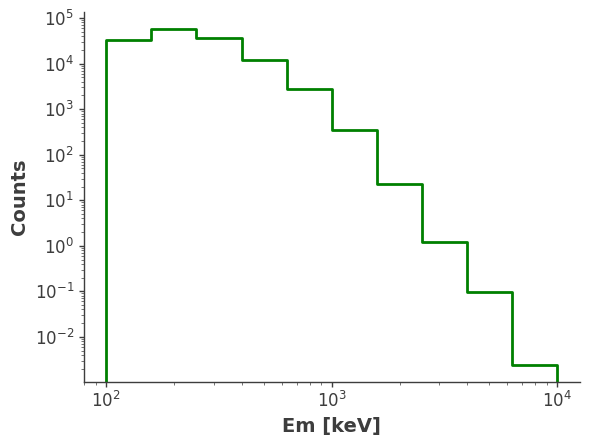

In [36]:
%%time

file_path = data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec264_DC3_COSI_cpl_pl_bright.hdf5"

# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)

# Get the data of the injected source
model_injected = injector.inject_model(model = model, orientation = ori, make_spectrum_plot = True, data_save_path = file_path)

# Combine background and source data

In [37]:
# ngc_hist = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5")
# ngc_hist = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl_pl.hdf5")
# ngc_hist = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl.hdf5")
# ngc_hist = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl_pl_faint.hdf5")
ngc_hist = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec264_DC3_COSI_cpl_pl_bright.hdf5")

In [38]:
TimeCut = 0.1490
# bkg_hist = Histogram.open(data_dir/"DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5")*TimeCut
bkg_hist = Histogram.open(data_dir/"DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")

In [39]:
ngc_hist.axes["Em"].axis_scale = "linear"

In [40]:
# We need to process the background and source data file to:
# 1. match the axes (including name and scale)
# 2. match the data unit

# collapse the time axis of the backgroun data
bkg_hist = bkg_hist.project(['Em', 'Phi', 'PsiChi'])

# reset the source data unit to the same one that the background data has
# bkg_hist = bkg_hist.to(unit = ngc_hist.unit)
ngc_hist = ngc_hist.to(unit = bkg_hist.unit, update = False)

In [41]:
for ax1, ax2 in zip(ngc_hist.axes, bkg_hist.axes):
    print(ax1.label)
    print(ax2.label)
    print("Equal?", ax1 == ax2)
    print()

Em
Em
Equal? True

Phi
Phi
Equal? True

PsiChi
PsiChi
Equal? True



In [ ]:
# bkg_hist.write(data_dir/"DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")

In [42]:
ngc_bkg = ngc_hist + bkg_hist
# ngc_bkg.write(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC4_COSI_cpl_pl_TimeCutBkg.hdf5")
# ngc_bkg.write(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_pl_TimeCutBkg.hdf5")
# ngc_bkg.write(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_TimeCutBkg.hdf5")
# ngc_bkg.write(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_pl_faint_TimeCutBkg.hdf5")
ngc_bkg.write(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec264_DC4_COSI_cpl_pl_bright_TimeCutBkg.hdf5")

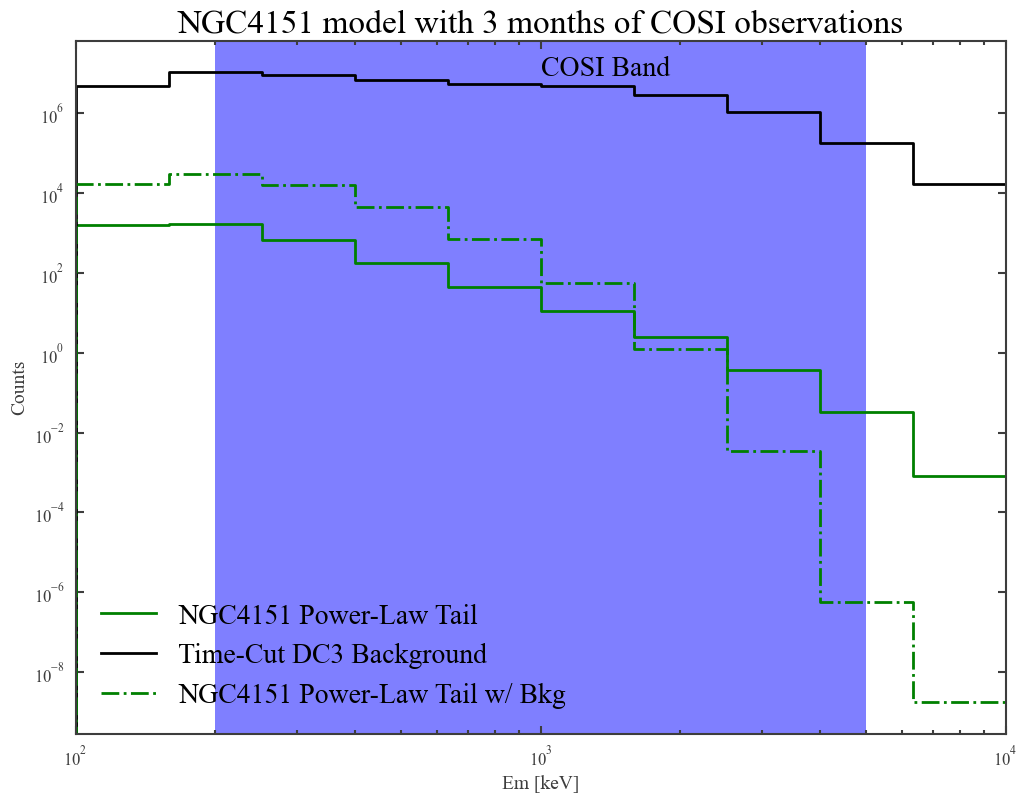

In [ ]:
NGC4151_ec200 = Histogram.open(data_dir/"AGN_Data/GammaRay/DC3/NGC_4151_ec200_DC3_COSI_PL_K0p1.hdf5")
bkg_hist = Histogram.open(data_dir/"AGN_Data/GammaRay/DC3/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut_NGC4151_TimeCut.hdf5")
NGC4151_ec200_bkg = Histogram.open(data_dir/"AGN_Data/GammaRay/DC3/NGC_4151_ec200_Totalbkg_COSI_PL_K0p1_TimeCut.hdf5")

plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(12, 9))

NGC4151_ec200.project("Em").draw(ax, label="NGC4151 Power-Law Tail", color="green")
bkg_hist.project("Em").draw(ax, label="Time-Cut DC3 Background", color="black")
NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC4151 Power-Law Tail w/ Bkg", linestyle='dashdot', color="green")

ax.xaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', top='on', pad=8)
ax.xaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', right='on', pad=8)
ax.yaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)


ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=20,  loc='lower left', frameon=False)
ax.set_ylabel("Counts")
ax.set_xlim(1e2, 1e4)
# ax.set_ylim(1e0, 1e9)
ax.axvspan(200, 5000, facecolor ='b', alpha = 0.5) 
ax.text(0.5, 0.95,'COSI Band', transform=ax.transAxes)
ax.set_title("NGC4151 model with 3 months of COSI observations")
plt.show()

### 0.2 - 5 MeV ###
# Sum_NGC4151_ec200 = np.sum(NGC4151_ec200.project("Em").slice[1:8])
# Sum_NGC4151_ec1000 = np.sum(NGC4151_ec1000.project("Em").slice[1:8])
# Sum_bkg_hist = np.sum(bkg_hist.project("Em").slice[1:8])
# Sigma_ec200 = Sum_NGC4151_ec200/(np.sqrt(Sum_NGC4151_ec200+Sum_bkg_hist))
# Sigma_ec1000 = Sum_NGC4151_ec1000/(np.sqrt(Sum_NGC4151_ec1000+Sum_bkg_hist))

# print("NGC4151 EC 200 Counts (0.2-5 MeV): ", Sum_NGC4151_ec200)
# print("NGC4151 EC 1000 Counts (0.2-5 MeV): ", Sum_NGC4151_ec1000)
# print("Background Counts (0.2-5 MeV): ", Sum_bkg_hist)
# print("Sigma EC 200: ", Sigma_ec200)
# print("Sigma EC 1000: ", Sigma_ec1000)

# ### 0.2 - 10 MeV ###
# TimeCut = 0.1936
# Sum_NGC4151_ec200 = np.sum(NGC4151_ec200.project("Em"))
# Sum_NGC4151_ec1000 = np.sum(NGC4151_ec1000.project("Em"))
# Sum_bkg_hist = np.sum(bkg_hist.project("Em"))*TimeCut
# Sigma_ec200 = Sum_NGC4151_ec200/(np.sqrt(Sum_NGC4151_ec200+Sum_bkg_hist))
# Sigma_ec1000 = Sum_NGC4151_ec1000/(np.sqrt(Sum_NGC4151_ec1000+Sum_bkg_hist))

# print("NGC4151 EC 200 Counts (0.2-10 MeV): ", Sum_NGC4151_ec200)
# print("NGC4151 EC 1000 Counts (0.2-10 MeV): ", Sum_NGC4151_ec1000)
# print("Background Counts (0.2-10 MeV): ", Sum_bkg_hist)
# print("Sigma EC 200: ", Sigma_ec200)
# print("Sigma EC 1000: ", Sigma_ec1000)

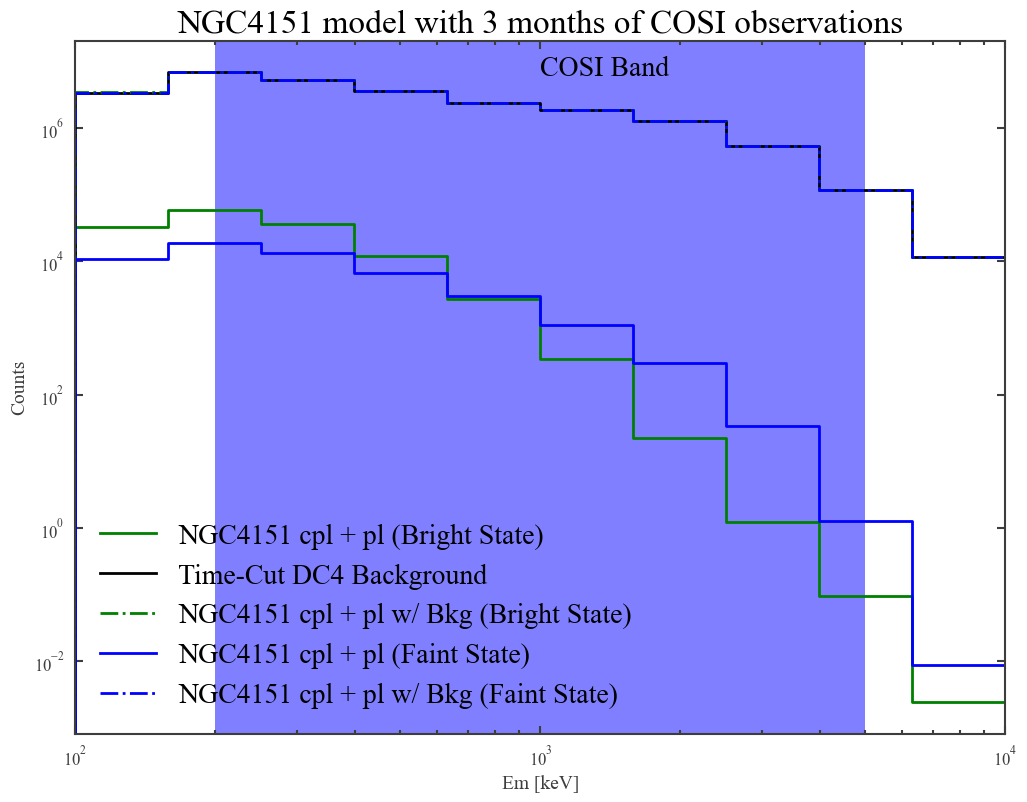

In [43]:
NGC4151_ec200 = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec264_DC3_COSI_cpl_pl_bright.hdf5")
bkg_hist = Histogram.open(data_dir/"DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")
NGC4151_ec200_bkg = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec264_DC4_COSI_cpl_pl_bright_TimeCutBkg.hdf5")
NGC4151_ec1000 = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl_pl_faint.hdf5")
NGC4151_ec1000_bkg = Histogram.open(data_dir/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_pl_faint_TimeCutBkg.hdf5")

plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(12, 9))

NGC4151_ec200.project("Em").draw(ax, label="NGC4151 cpl + pl (Bright State)", color="green")
bkg_hist.project("Em").draw(ax, label="Time-Cut DC4 Background", color="black")
NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC4151 cpl + pl w/ Bkg (Bright State)", linestyle='dashdot', color="green")
NGC4151_ec1000.project("Em").draw(ax, label="NGC4151 cpl + pl (Faint State)", color="blue")
NGC4151_ec1000_bkg.project("Em").draw(ax, label="NGC4151 cpl + pl w/ Bkg (Faint State)", linestyle='dashdot', color="blue")

ax.xaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', top='on', pad=8)
ax.xaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', right='on', pad=8)
ax.yaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)


ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=20,  loc='lower left', frameon=False)
ax.set_ylabel("Counts")
ax.set_xlim(1e2, 1e4)
# ax.set_ylim(1e0, 1e9)
ax.axvspan(200, 5000, facecolor ='b', alpha = 0.5) 
ax.text(0.5, 0.95,'COSI Band', transform=ax.transAxes)
ax.set_title("NGC4151 model with 3 months of COSI observations")
plt.show()

### 0.2 - 5 MeV ###
# Sum_NGC4151_ec200 = np.sum(NGC4151_ec200.project("Em").slice[1:8])
# Sum_NGC4151_ec1000 = np.sum(NGC4151_ec1000.project("Em").slice[1:8])
# Sum_bkg_hist = np.sum(bkg_hist.project("Em").slice[1:8])
# Sigma_ec200 = Sum_NGC4151_ec200/(np.sqrt(Sum_NGC4151_ec200+Sum_bkg_hist))
# Sigma_ec1000 = Sum_NGC4151_ec1000/(np.sqrt(Sum_NGC4151_ec1000+Sum_bkg_hist))

# print("NGC4151 EC 200 Counts (0.2-5 MeV): ", Sum_NGC4151_ec200)
# print("NGC4151 EC 1000 Counts (0.2-5 MeV): ", Sum_NGC4151_ec1000)
# print("Background Counts (0.2-5 MeV): ", Sum_bkg_hist)
# print("Sigma EC 200: ", Sigma_ec200)
# print("Sigma EC 1000: ", Sigma_ec1000)

# ### 0.2 - 10 MeV ###
# TimeCut = 0.1936
# Sum_NGC4151_ec200 = np.sum(NGC4151_ec200.project("Em"))
# Sum_NGC4151_ec1000 = np.sum(NGC4151_ec1000.project("Em"))
# Sum_bkg_hist = np.sum(bkg_hist.project("Em"))*TimeCut
# Sigma_ec200 = Sum_NGC4151_ec200/(np.sqrt(Sum_NGC4151_ec200+Sum_bkg_hist))
# Sigma_ec1000 = Sum_NGC4151_ec1000/(np.sqrt(Sum_NGC4151_ec1000+Sum_bkg_hist))

# print("NGC4151 EC 200 Counts (0.2-10 MeV): ", Sum_NGC4151_ec200)
# print("NGC4151 EC 1000 Counts (0.2-10 MeV): ", Sum_NGC4151_ec1000)
# print("Background Counts (0.2-10 MeV): ", Sum_bkg_hist)
# print("Sigma EC 200: ", Sigma_ec200)
# print("Sigma EC 1000: ", Sigma_ec1000)